In [1]:
!pip install pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

y = df['SalePrice']

In [5]:
print(X.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = model.predict(X_test)

In [9]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 35788.061292436294
MSE : 2806426667.247853
RMSE : 52975.71771338122
R2 Score : 0.6341189942328371


In [10]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(result.head(10))

      Actual Price  Predicted Price
892         154500    113410.672553
1105        325000    305081.877759
413         115000    135904.785630
522         159000    205424.675641
1036        315500    227502.683490
614          75500    121157.480796
218         311500    205577.980566
1160        146000    183787.203783
649          84500    121157.480796
887         135500    147219.222332


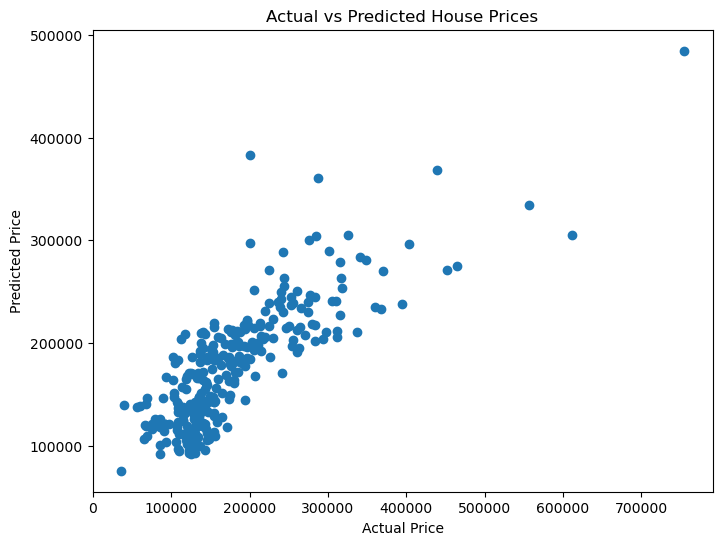

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [12]:
new_house = [[2000, 3, 2]]

predicted_price = model.predict(new_house)

print("Predicted Price: $", predicted_price[0])

Predicted Price: $ 240377.51479736282


D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
